In [2]:
import csv
import numpy as np

# Size taken from the dataset and is known
X = np.zeros((351, 34), dtype='float')
y = np.zeros((351,), dtype='bool')
data_filename = 'ionosphere/ionosphere.data'

with open(data_filename, 'r') as input_file:
    reader = csv.reader(input_file)
    for i, row in enumerate(reader):
        # Get the data, converting each item to a float
        data = [float(datum) for datum in row[:-1]]
        # Set the appropriate row in our dataset
        X[i] = data
        # 1 if the class is 'g', 0 otherwise
        y[i] = row[-1] == 'g'

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=14)
print("There are {} samples in the training dataset".format(X_train.shape[0]))
print("There are {} samples in the testing dataset".format(X_test.shape[0]))
print("Each sample has {} features".format(X_train.shape[1]))

There are 263 samples in the training dataset
There are 88 samples in the testing dataset
Each sample has 34 features


In [ ]:
print(X_train[:5])
print(y_train[:5])
print(X_test[:5])
print(y_test[:5])

[[ 0.       0.       1.       1.       1.      -1.       0.       0.
   0.       0.       1.       1.       1.       1.      -1.      -1.
   1.      -1.      -1.       1.       0.       0.       1.      -1.
   1.      -1.       1.       1.      -1.      -1.       0.       0.
   0.       0.     ]
 [ 1.       0.       1.      -0.06182  1.       0.02942  1.      -0.05131
   1.      -0.01707  1.      -0.11726  0.84493 -0.05202  0.93392 -0.06598
   0.6917  -0.07379  0.65731 -0.20367  0.9491  -0.31558  0.80852 -0.31654
   0.84932 -0.34838  0.72529 -0.29174  0.73094 -0.38576  0.54356 -0.26284
   0.64207 -0.39487]
 [ 0.       0.       0.       0.       0.       0.       0.       0.
   0.       0.       0.       0.       0.       0.       0.       0.
   0.       0.       0.       0.       0.       0.       0.       0.
   0.       0.       1.       0.       0.       0.       0.       0.
   0.       0.     ]
 [ 1.       0.      -1.       0.28105  0.22222  0.15033 -0.75693 -0.70984
  -0.30719  0.7

In [13]:
from sklearn.neighbors import KNeighborsClassifier

estimator = KNeighborsClassifier()

In [14]:
estimator.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [6]:
y_predicted = estimator.predict(X_test)
accuracy = np.mean(y_test == y_predicted) * 100
print("The accuracy is {0:.1f}%".format(accuracy))

The accuracy is 86.4%


In [7]:
from sklearn.model_selection import cross_val_score

In [8]:
scores = cross_val_score(estimator, X, y, scoring='accuracy')
average_accuracy = np.mean(scores) * 100
print("The average accuracy is {0:.1f}%".format(average_accuracy))

The average accuracy is 82.6%


In [9]:
avg_scores = []
all_scores = []
parameter_values = list(range(1, 21))  # Including 20
for n_neighbors in parameter_values:
    estimator = KNeighborsClassifier(n_neighbors=n_neighbors)
    scores = cross_val_score(estimator, X, y, scoring='accuracy')
    avg_scores.append(np.mean(scores))
    all_scores.append(scores)

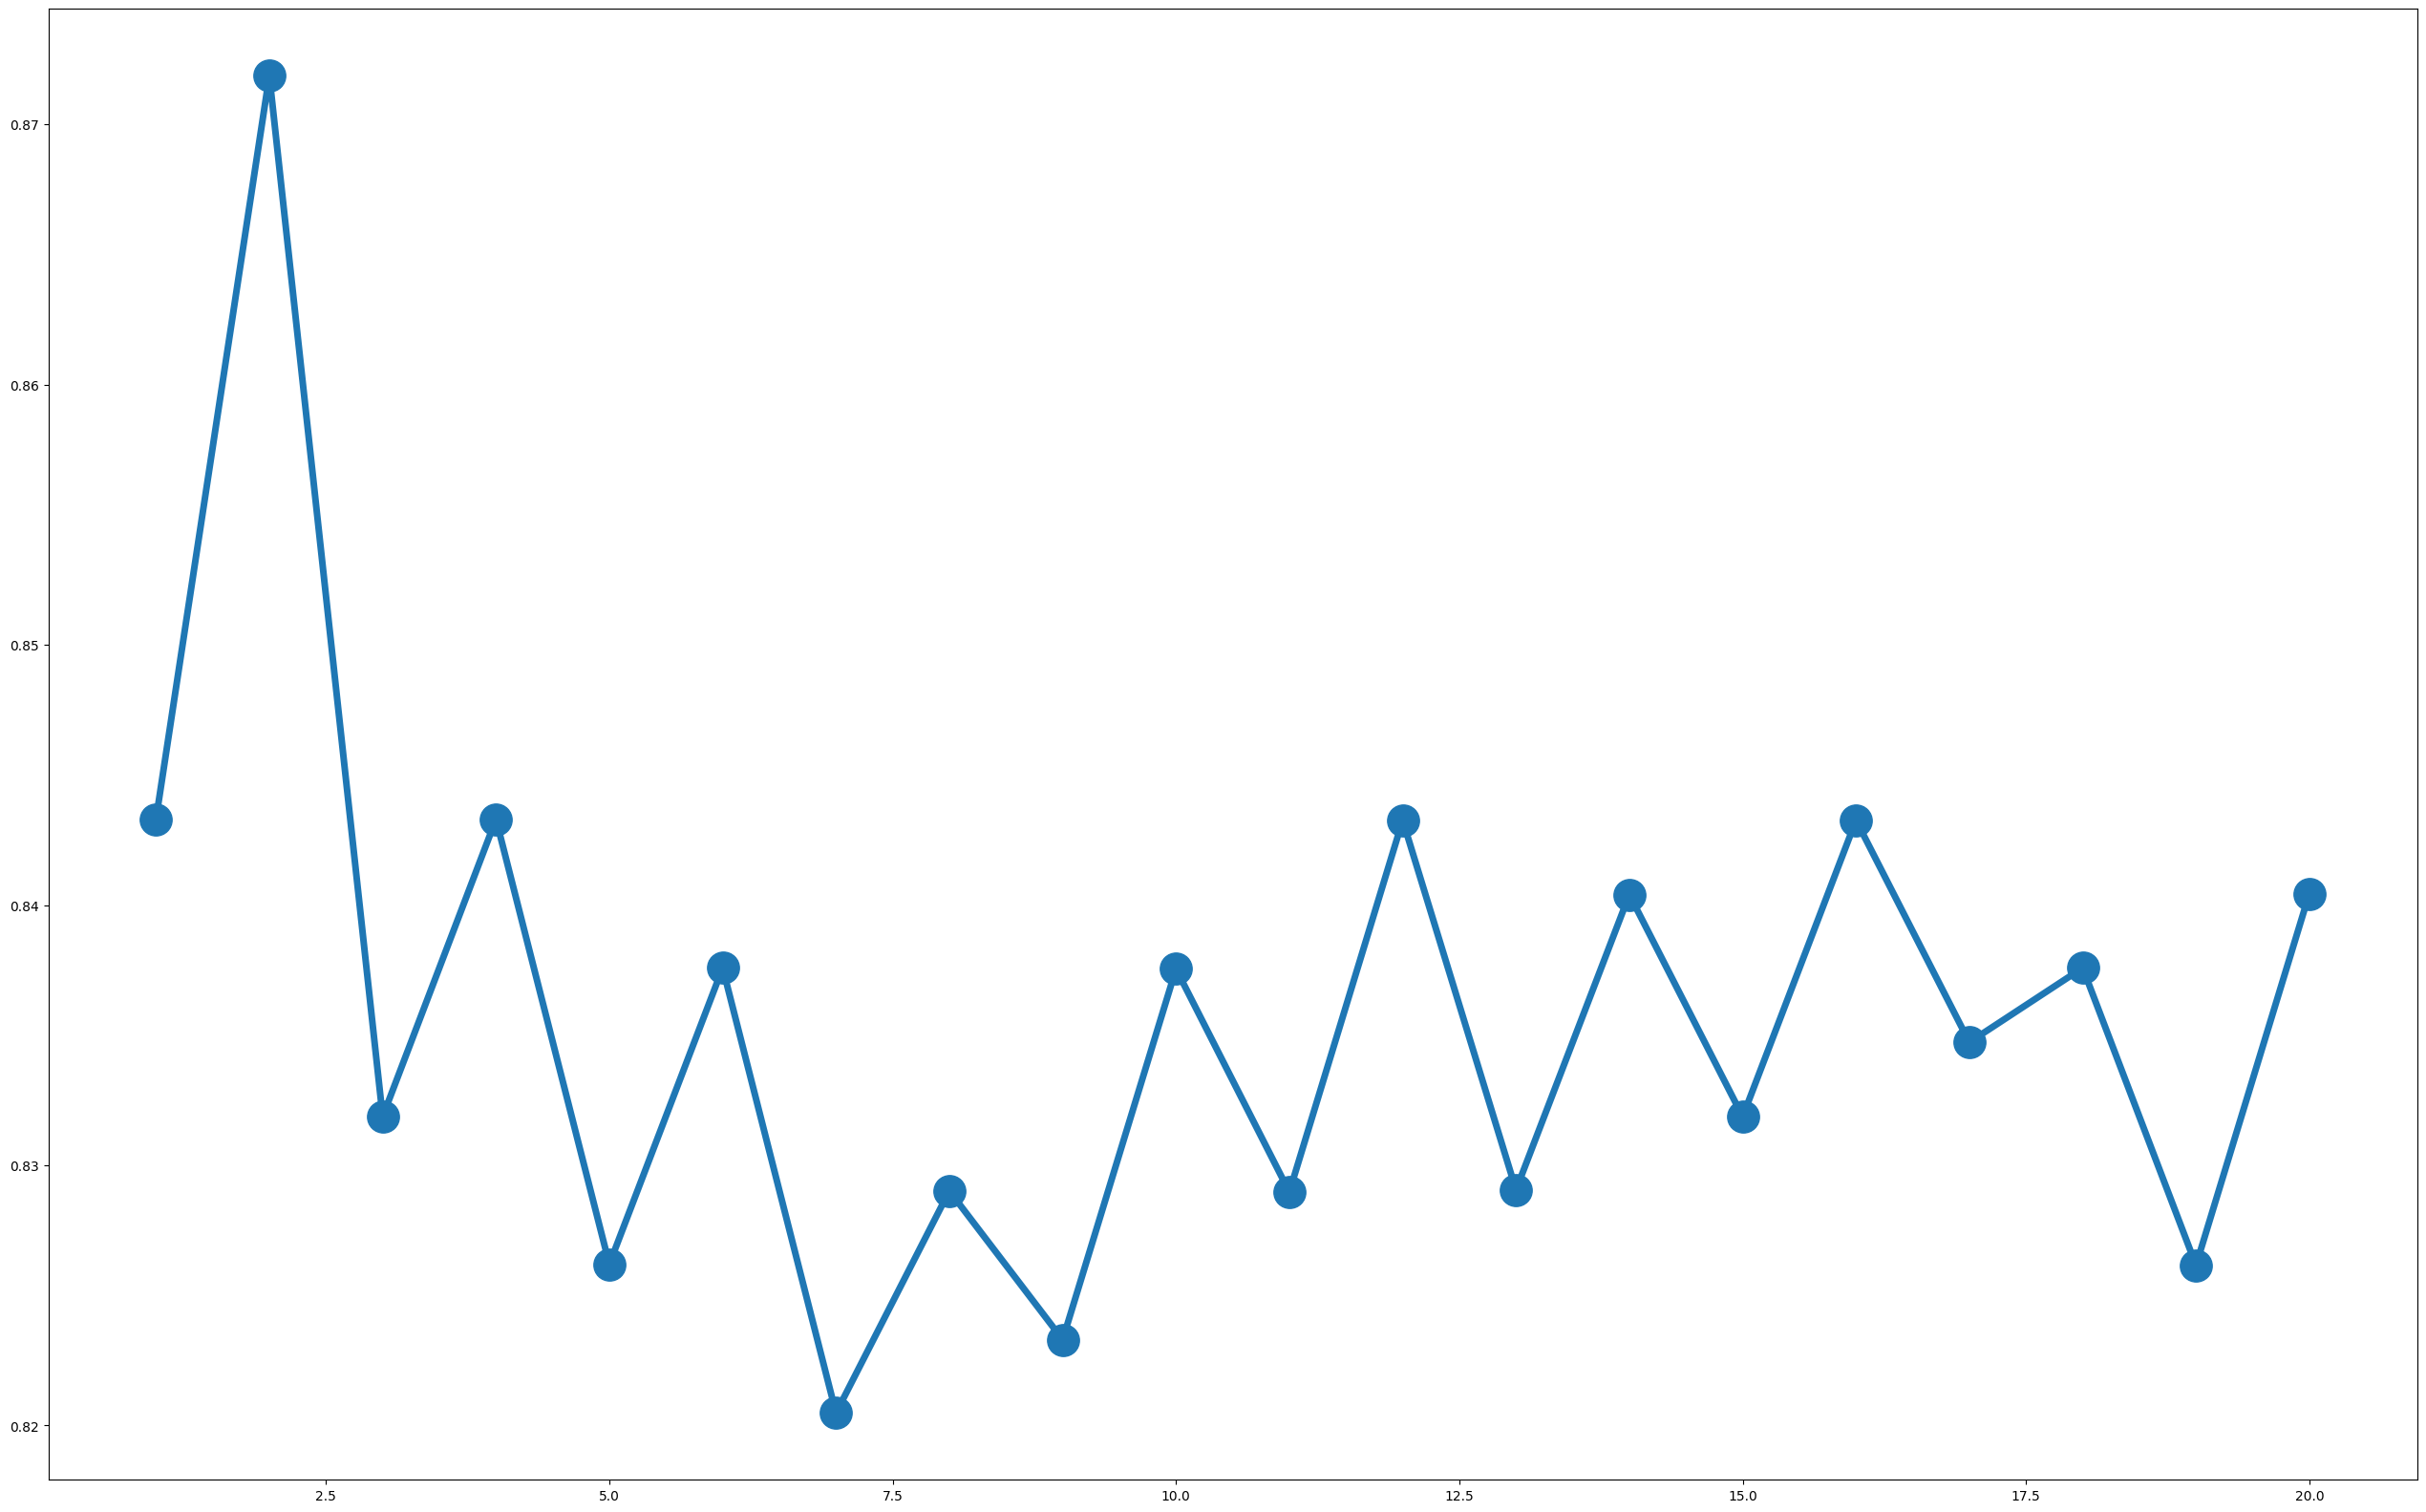

In [23]:
from matplotlib import pyplot as plt
plt.figure(figsize=(32,20))
plt.plot(parameter_values, avg_scores, '-o', linewidth=5, markersize=24)
#plt.axis([0, max(parameter_values), 0, 1.0])

(np.float64(0.0), np.float64(20.0), np.float64(0.7), np.float64(1.0))

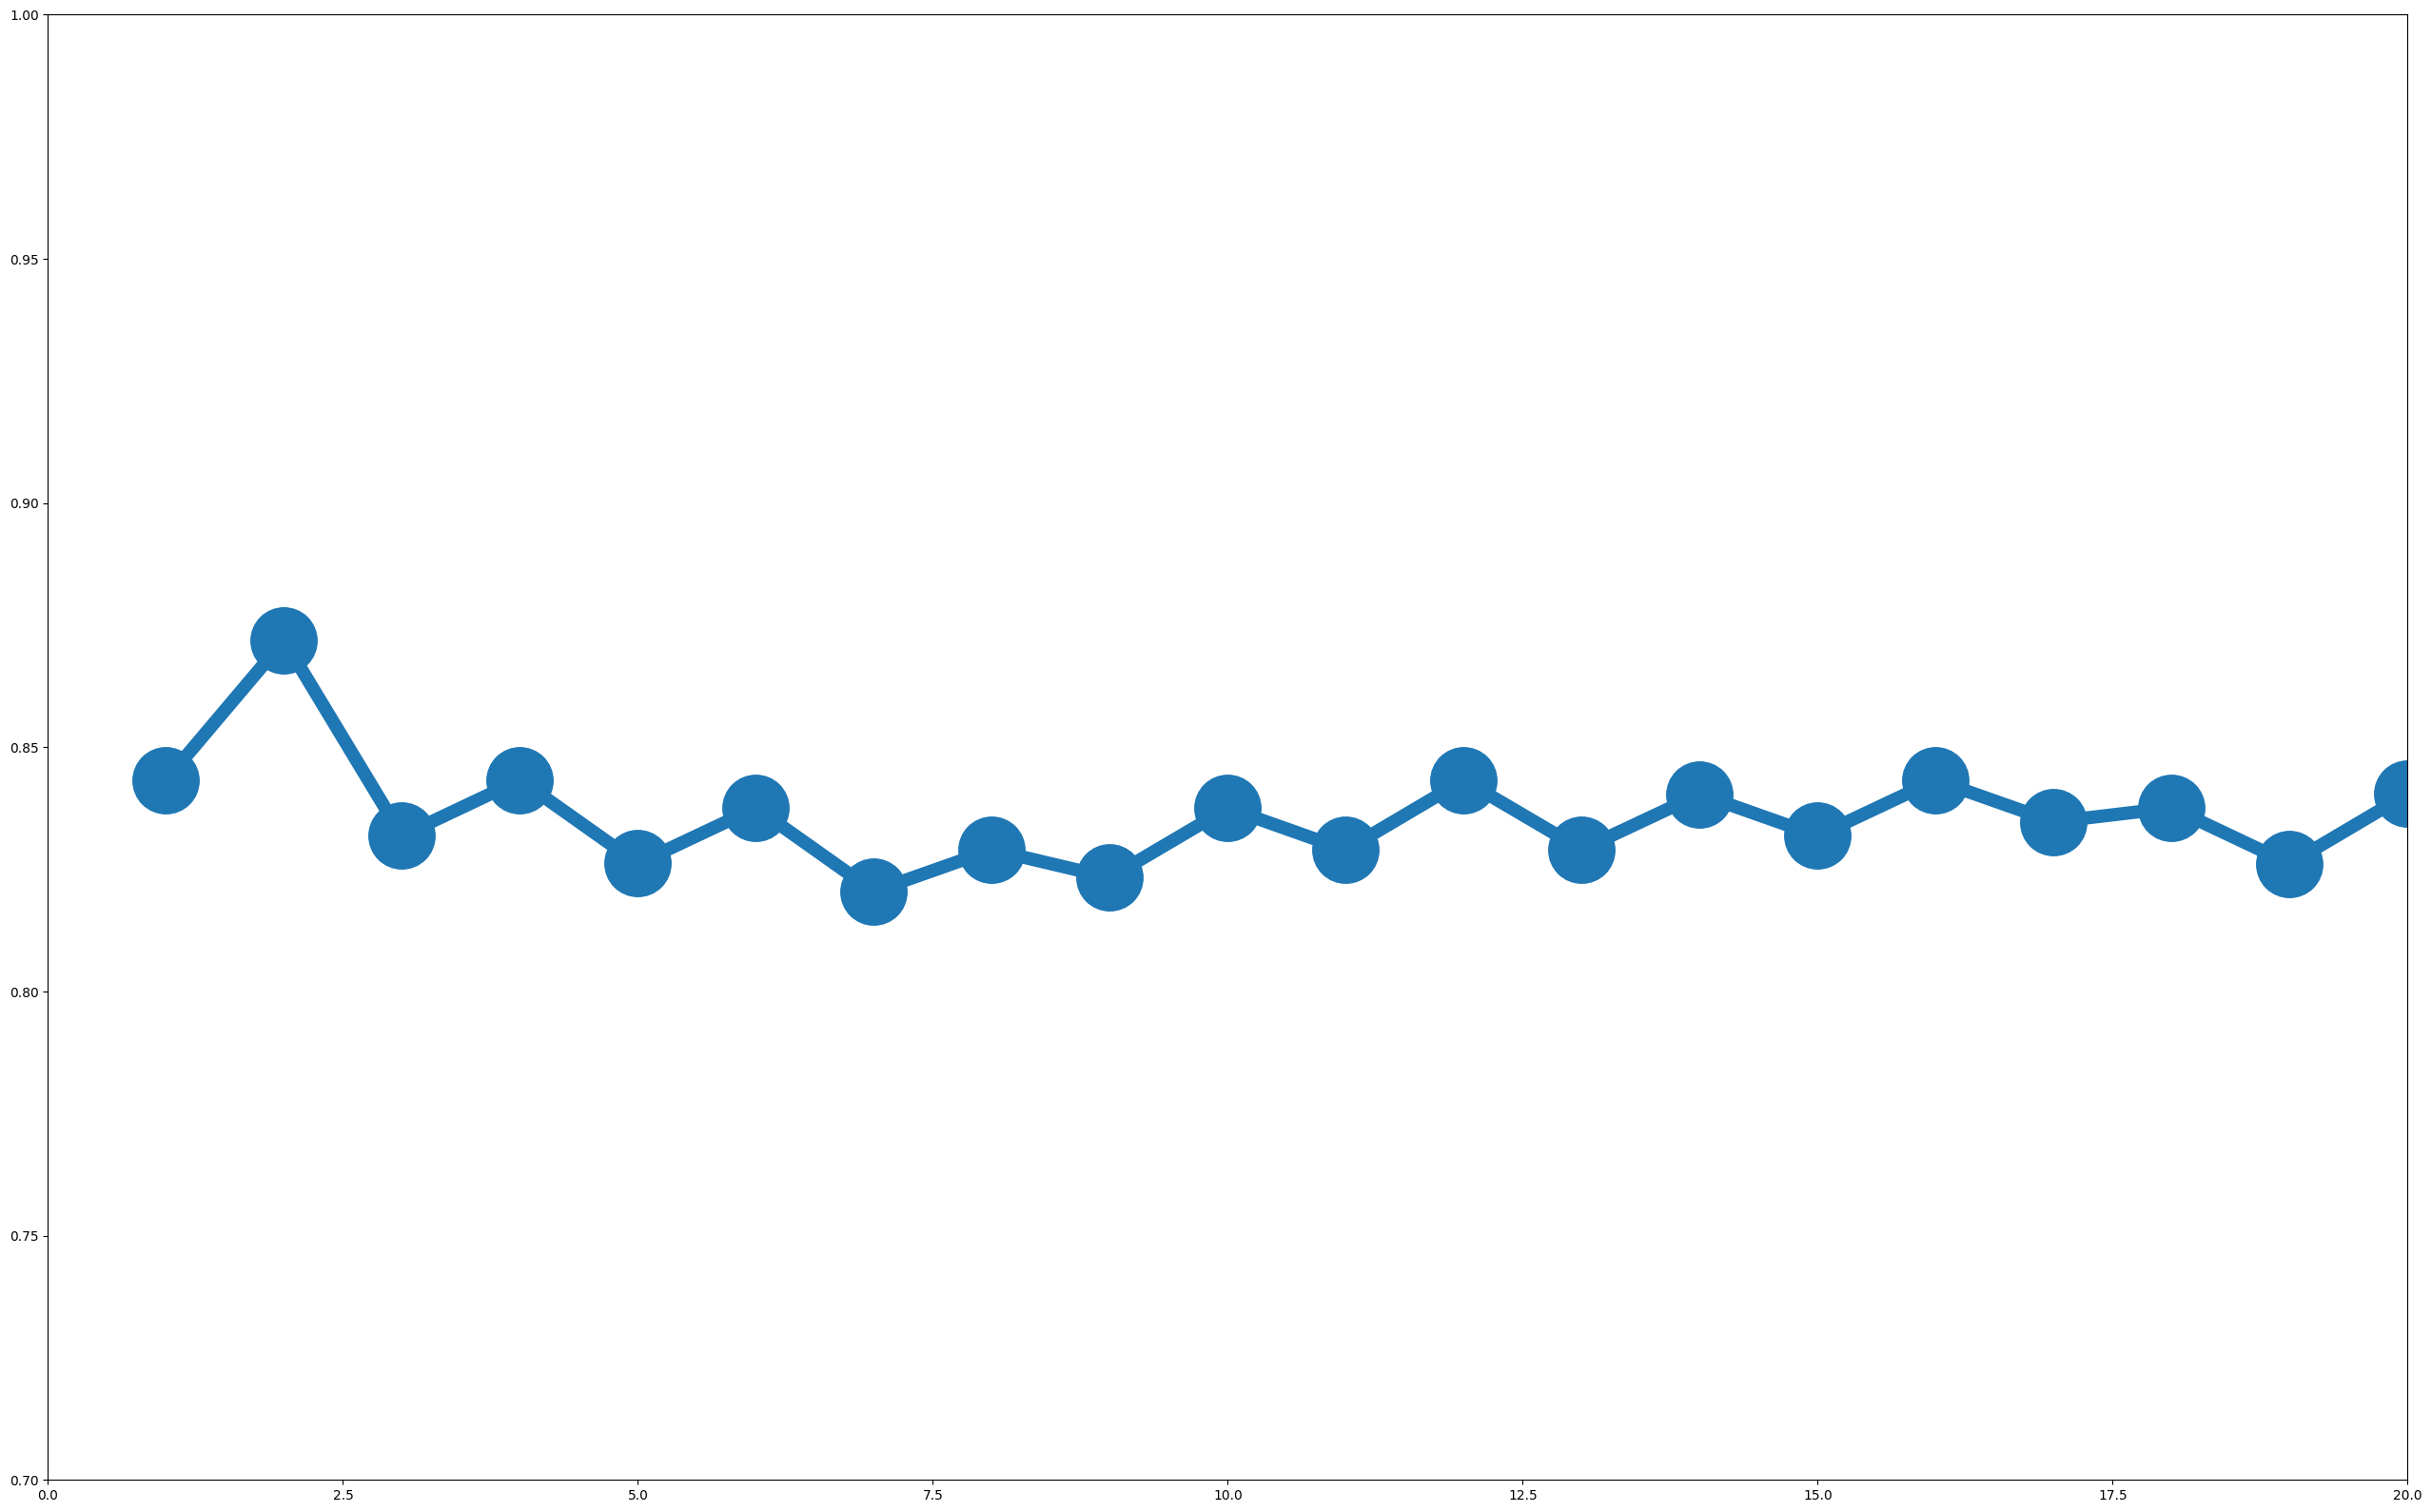

In [32]:
from matplotlib import pyplot as plt
plt.figure(figsize=(32,20))
plt.plot(parameter_values, avg_scores, '-o', linewidth=10, markersize=50)
plt.axis([0, max(parameter_values), 0.7, 1.0])

[[1.       0.       0.997695 0.470555 0.926215 0.51153  0.91699  0.31146
  1.       0.5188   0.926215 0.411225 0.798775 0.275275 0.80268  0.308885
  0.92178  0.30729  0.79106  0.33904  0.784855 0.35163  0.68473  0.263215
  0.784055 0.244145 0.70539  0.26916  0.60633  0.32955  0.711335 0.227565
  0.593205 0.2735  ]
 [1.       0.       1.       0.405855 0.965175 0.31922  0.44566  0.032015
  1.       0.477255 0.75437  0.161285 0.67216  0.151465 0.241575 0.012425
  0.527495 0.188815 0.665545 0.       0.434245 0.2735   0.40972  0.32133
  0.39834  0.367155 0.39766  0.407995 0.4048   0.442035 0.41687  0.46856
  0.43131  0.487765]
 [1.       0.       1.       0.483175 1.       0.502425 1.       0.43969
  0.944825 0.50599  0.86541  0.52673  0.927215 0.504135 0.772955 0.501495
  0.918875 0.43178  0.877675 0.4573   0.854435 0.36249  0.716925 0.43969
  0.78764  0.2989   0.79492  0.389275 0.7155   0.413175 0.80218  0.3791
  0.780225 0.30881 ]
 [1.       0.       1.       0.274195 1.       1.       

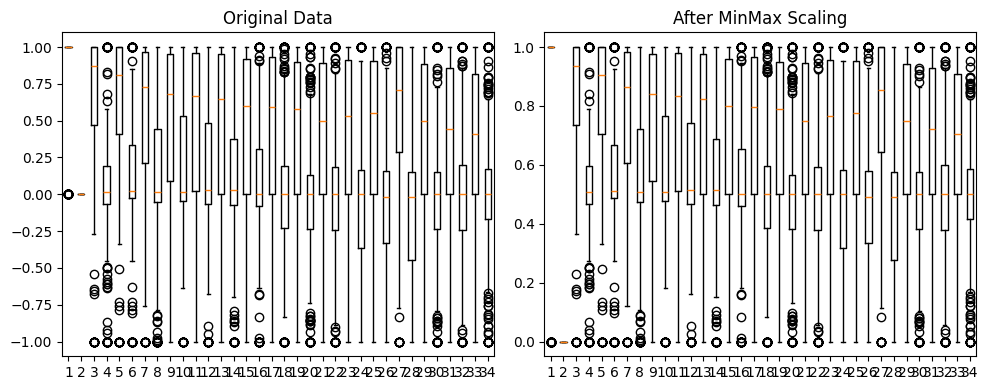

In [37]:
from sklearn.preprocessing import MinMaxScaler
X_transformed = MinMaxScaler().fit_transform(X)
print(X_transformed[:5])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.boxplot(X)
plt.title("Original Data")

plt.subplot(1,2,2)
plt.boxplot(X_transformed)
plt.title("After MinMax Scaling")

plt.tight_layout()
plt.show()

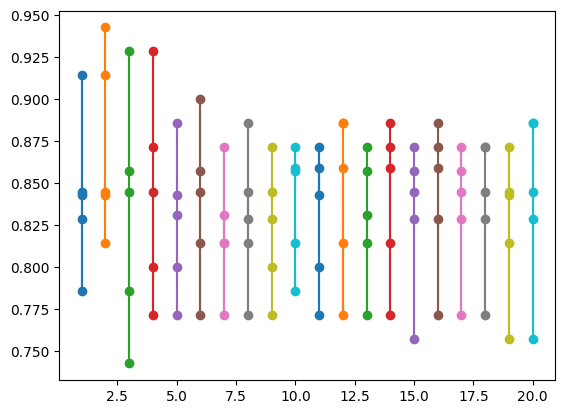

In [17]:
for parameter, scores in zip(parameter_values, all_scores):
    n_scores = len(scores)
    plt.plot([parameter] * n_scores, scores, '-o')

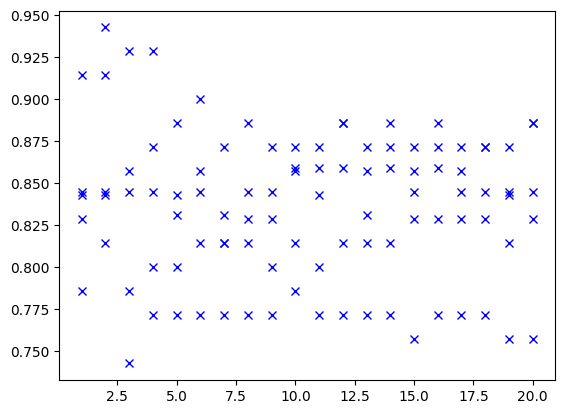

In [18]:
plt.plot(parameter_values, all_scores, 'bx')

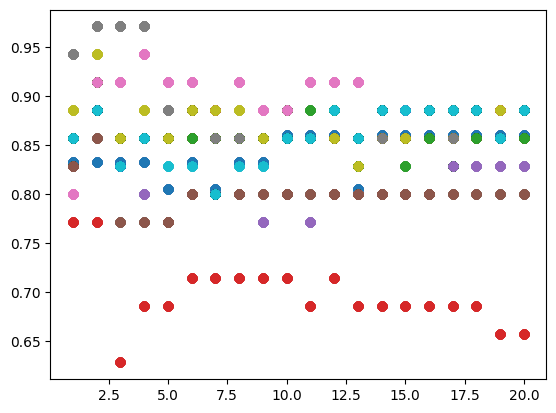

In [19]:
from collections import defaultdict
all_scores = defaultdict(list)
parameter_values = list(range(1, 21))  # Including 20
for n_neighbors in parameter_values:
    for i in range(100):
        estimator = KNeighborsClassifier(n_neighbors=n_neighbors)
        scores = cross_val_score(estimator, X, y, scoring='accuracy', cv=10)
        all_scores[n_neighbors].append(scores)
for parameter in parameter_values:
    scores = all_scores[parameter]
    n_scores = len(scores)
    plt.plot([parameter] * n_scores, scores, '-o')